<a href="https://colab.research.google.com/github/jaewoo0108/ml/blob/main/week05-logistic-regression/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5: 로지스틱 회귀와 정규화

##  핵심 개념
- **Logistic Regression**: sigmoid 함수

- **Regularization**

0.5
0.9999546021312976
[4.53978687e-05 5.00000000e-01 9.99954602e-01]


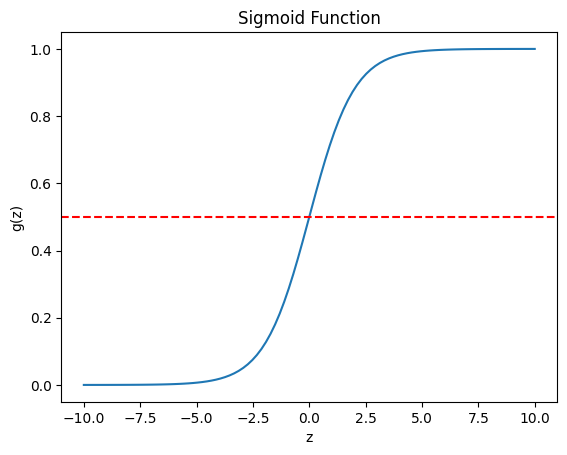

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 시그모이드 함수 구현
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

print(sigmoid(0))
print(sigmoid(10))
a = np.array([-10, 0, 10])

print(sigmoid(a))


# 시그모이드 곡선 그리기
z = np.linspace(-10,10, 100)
g = sigmoid(z)

plt.plot(z,g)

plt.axhline(y = 0.5, color = "red", linestyle="--")
plt.xlabel("z")
plt.ylabel("g(z)")
plt.title("Sigmoid Function")

plt.show()

In [ ]:
# 손실은 얼마나 틀렸는가를 재는 값이기에 완벽하면 0, 많이 틀릴수록 커지기에 손실이 음수이면 안된다

def logistic_loss(f, y):
  return -y * np.log(f) -(1-y) * np.log(1-f)

print(logistic_loss(0.99, 1))
print(logistic_loss(0.01, 1))
print(logistic_loss(0.98, 0))
print(logistic_loss(0.01, 0))

0.01005033585350145
4.605170185988091
3.912023005428145
0.01005033585350145


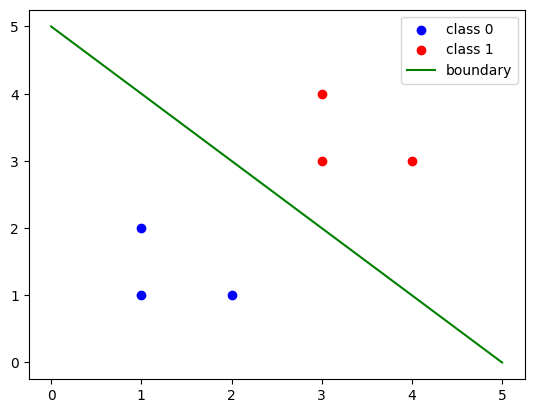

In [ ]:
# 결정 경계 구하기

X = np.array([[1,1], [1,2], [2,1], [3,3], [3,4], [4,3]])
y = np.array([0,0,0,1,1,1])

plt.scatter( X[y==0, 0], X[y==0, 1], color = "blue", label="class 0")
plt.scatter( X[y==1, 0], X[y==1, 1], color = "red", label="class 1")

w = np.array([1,1])
b = -5

# 경계선: x1의 양 끝점 두 개에 대해 x2 계산
x1_line = np.array([0, 5])
x2_line = -(w[0]*x1_line + b) / w[1]
plt.plot(x1_line, x2_line, color="green", label="boundary")

plt.legend()
plt.show()

In [ ]:
# sklearn과의 결과 비교
import sklearn
from sklearn.linear_model import LogisticRegression

X = np.array([[1,1], [1,2], [2,1], [3,3], [3,4], [4,3]])
y = np.array([0,0,0,1,1,1])

lr_model = LogisticRegression()
lr_model.fit(X,y)
y_pred = lr_model.predict(X)
lr_model.score(X,y)

print(lr_model.coef_)
print(lr_model.intercept_)

[[0.86837936 0.86837936]]
[-4.05066002]


In [ ]:
# 정규화 벌점항 구현

def reg_penalty(w,m, lambda_):
  return (lambda_ / (2*m)) * np.sum(w**2)

w = np.array([0.1, 0.2, 0.1])
print(reg_penalty(w,10,1))

w = np.array([5, 8, 6])
print(reg_penalty(w,10,1))

0.003000000000000001
6.25


In [ ]:
# sklearn에서 (C = 1/λ)인 C를 바꿔가며 규제 강할 때와 약할 때를 비교

X = np.array([[1,1],[1,2],[2,1],[3,3],[3,4],[4,3]])
y = np.array([0,0,0,1,1,1])

for C in [0.01, 100]:
    model = LogisticRegression(C=C)
    model.fit(X, y)
    가중치크기 = np.sum(np.abs(model.coef_))   # coef_는 도전 5에서 봤지
    정확도 = model.score(X, y)                  # score도 도전 5에서 썼지
    print(f"C={C}: 가중치크기={가중치크기:.2f}, 정확도={정확도}")

C=0.01: 가중치크기=0.06, 정확도=1.0
C=100: 가중치크기=5.83, 정확도=1.0


In [ ]:
## 정리

- 로지스틱 회귀는 시그모이드 함수 기반으로 구현

- 손실 함수는 예측이 얼마나 틀렸는지 나타내는 값이기에 음수 값이 출력되면 안된다 (0 ~ 양수)

- 결정 경계는 시그모이드 함수 g(z)가 0.5인 부분, 즉 z = 0인 지점   //  (z = w·x + b)

- 입력 데이터들의(x) 범위를 맞추는 feature scaling도 정규화(Normalization), 데이터가 아니라 가중치(w)를 작게 만드는 방법도 정규화(Regularization)

- 람다값을 크게 설정해서 규제를 강하게하면 그만큼 가중치의 크기 최소화, 과적합 방지 (= 각 특성이 출력에 주는 영향이 약해지므로 모델 전체가 완만해지고 단순해진다)

- 람다값을 작게 설정하면 훈련 오차를 최소화, 과적합 위험 (= 개별 데이터 하나하나에 모두 예민하게 반응하기에 쓸데없는 노이즈까지 학습)

-> 약한 규제는 훈련 오차가 낮아 정확도는 높지만 훈련데이터를 과도하게 학습하게 되어서 과적합 발생 -> 더 나쁜 모델